# Group 38 - Abigail Caddick, Rebekah Lee, and Lauriston Prescott Jr
# Project Milestone One: Form Your Team, Understand the Problem, and Explore the Data

#### **Due:** July 12th @ 11:59 PM (with a 2 hour & 1 minute grace period)

#### **Important:** There is **no late period** for this assignment, as manual grading must begin immediately after the deadline.

## What You Will Do in This Milestone

1. Form your project team and complete the **Team Contract** (available in the Homework Repository). Submit one copy to Gradescope.
2. Select a **team leader**, who will submit this notebook on behalf of the team after everyone has contributed to the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>Gradescope guide</a> explains how to add group members to a submission.
3. After completing this milestone, **each team member** must complete an **Individual Team Evaluation** (available in the Homework Repository) and submit it individually to Gradescope.
4. Complete a simplified version of the **Machine Learning Project Checklist** from Appendix A of *Hands-On Machine Learning* (p. 779):

> **Part 1:** Frame the problem and understand the project goals   
> **Part 2:** Explore and understand the dataset   
> **Part 3:** Clean and prepare the data   
> **Part 4:** Investigate feature relationships   
> **Part 5:** Develop hypotheses for feature engineering and preprocessing

## The Dataset

All teams will work with the same dataset: a reduced version of the Zillow housing dataset used in the **Zillow Prize** competition on Kaggle in 2017 (unfortunately, the competition has long since ended!).

Your goal is to predict a property's **assessed tax value** (`taxvaluedollarcnt`) from a large collection of property characteristics. The dataset contains many of the challenges encountered in real machine learning projects, including:

* Missing values
* Potential outliers
* Redundant and highly correlated features
* Identifier variables that may not be useful for prediction
* Features that require careful interpretation before preprocessing

Unlike many educational datasets, this one has **not** been extensively preprocessed. Throughout this milestone, your objective is to understand the data, identify potential issues, and develop hypotheses about preprocessing and feature engineering. In **Milestone 2**, you will evaluate many of these ideas experimentally to determine whether they actually improve model performance.



In [ ]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.**

For a detailed description of the dataset features, please refer to  **Appendix 1** below.


In [ ]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


## Part 1: Frame the problem and look at the big picture [3 pts] - Lauriston

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercising all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data;
- Develop a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:**

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

> The objective of this project is to predict the assessed tax value of a property from its features. People trust Zillow because of the accurate numbers it provides. If we can predict the taxvaluedollarcnt accurately, trust will follow. This trust encourages users to return, explore listings, use Zillow's tools, and take part in services like Zillow Offers, where the company buys and sells homes. The profits from the Zillow Offered deals that come with it will make all the work from creating an accurate analysis worth it.


**1.2:**  How will your solution be used?

> The solution will be used to help customers better choose the property vaule they are looking for. This gives buyers and sellers an independent, data-based reference next to the listing price, which helps them decide if a home is fairly priced. The marketing team could look at gaps between predicted and actual values to spot undervalued or overvalued markets and adjust their strategy. The predicted value of homes may help the sales team target their campagins for different client bases, such as first time buyers or by region. Teams at Zillow won't be the only ones benfiting, if Zillow is considering buying homes, the model’s output could help decide which regions or property types to focus on for outreach or advertising.

**1.3:**  How should success (or failure) be measured?

> We can use RMSE to measure the success of our project. It can show us exactly how much our predictions differ from actual tax values in dollar terms. However, if there are too many outliers the RMSE will skew off the average. That is why it is important to check its error. It can also be misleading because it squares errors before averaging, maiking it very sensitive to outliers. Just a few ouliers and the model will throw off the whole system. If we are able to create predictions without the RMSE being affected by the outliers, we have succeeded.

## Part 2: Download and perform preliminary exploration of the data [4 pts] - Becka

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Feature Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process.
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [ ]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [ ]:
df.info()

# 55 cols with 77613 rows
# first inspection shows some null values, will dive deeper into those shortly
# target is taxvaluedollarcnt and has 77578 entires - that means some are missing (will probably need to drop as discussed in the live session)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [ ]:
missing = df.isnull().sum()
pct = (missing / len(df)) * 100
report = pd.DataFrame({'missing_count': missing, 'missing_pct': pct})
final_report = report[report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(final_report)
# wow many features with over 90% null values! i think i counted 20, I'm inclinced to drop these cols as they won't be very meaningful with that amount of missing data.
# need to decide on the % threshold for the other cols
# target taxvaluedollarcnt has 35 null values
# some columns are missing basically all of the data

                              missing_count  missing_pct
buildingclasstypeid                   77598    99.980673
finishedsquarefeet13                  77571    99.945885
basementsqft                          77563    99.935578
storytypeid                           77563    99.935578
yardbuildingsqft26                    77543    99.909809
fireplaceflag                         77441    99.778388
architecturalstyletypeid              77406    99.733292
typeconstructiontypeid                77390    99.712677
finishedsquarefeet6                   77227    99.502661
pooltypeid10                          77148    99.400874
decktypeid                            76999    99.208895
poolsizesum                           76744    98.880342
pooltypeid2                           76539    98.616211
hashottuborspa                        76074    98.017085
yardbuildingsqft17                    75220    96.916754
taxdelinquencyflag                    74713    96.263513
taxdelinquencyyear             

In [ ]:
df.describe()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,assessmentyear,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
count,7.761300e+04,25007.000000,207.000000,50.000000,77579.000000,77579.000000,15.000000,49809.000000,76963.000000,614.0,...,223.000000,50703.000000,2393.000000,70.000000,77309.000000,17599.000000,77579.0,2900.000000,7.733200e+04,7.757800e+04
mean,1.300781e+07,1.812013,7.386473,679.720000,2.298496,3.053223,3.933333,6.533779,2.316392,66.0,...,6.040359,1.110309,305.460928,216.385714,1968.611507,1.434286,2016.0,14.088276,6.049667e+13,4.901506e+05
std,3.518717e+06,2.965768,2.728030,689.703546,0.996732,1.140480,0.258199,1.722062,0.979689,0.0,...,0.556035,1.169967,238.735241,190.177514,23.793171,0.544515,0.0,2.181281,1.533339e+12,6.537979e+05
min,1.071186e+07,1.000000,2.000000,38.000000,0.000000,0.000000,3.000000,1.000000,1.000000,66.0,...,4.000000,1.000000,11.000000,12.000000,1824.000000,1.000000,2016.0,3.000000,6.037101e+13,1.000000e+03
25%,1.153821e+07,1.000000,7.000000,273.000000,2.000000,2.000000,4.000000,6.000000,2.000000,66.0,...,6.000000,1.000000,170.000000,61.500000,1953.000000,1.000000,2016.0,14.000000,6.037311e+13,2.068985e+05
50%,1.253004e+07,1.000000,7.000000,515.000000,2.000000,3.000000,4.000000,6.000000,2.000000,66.0,...,6.000000,1.000000,250.000000,164.500000,1970.000000,1.000000,2016.0,15.000000,6.037603e+13,3.588785e+05
75%,1.421101e+07,1.000000,7.000000,796.500000,3.000000,4.000000,4.000000,8.000000,3.000000,66.0,...,6.000000,1.000000,364.000000,310.500000,1987.000000,2.000000,2016.0,15.000000,6.059042e+13,5.690000e+05
max,1.676893e+08,13.000000,21.000000,3560.000000,18.000000,16.000000,4.000000,12.000000,18.000000,66.0,...,13.000000,237.000000,3191.000000,868.000000,2016.000000,6.000000,2016.0,99.000000,4.830301e+14,4.906124e+07


In [ ]:
df.nunique().sort_values(ascending=False)
# decktypeid, hashottuborspa, poolcnt, pooltypeid10, pooltypeid2, pooltypeid7 only have 1 unique value - likely not going to be helpful for our models
# also look at which ones have too many..parcelid, latitude, longitude, rawcensustractandblock, censustractandblock, lotsizesquarefeet
  # taxvaluedollarcnt (keep this is our target)

,0
parcelid,77414
latitude,64038
longitude,62461
taxvaluedollarcnt,50949
rawcensustractandblock,39188
censustractandblock,39006
lotsizesquarefeet,18848
calculatedfinishedsquarefeet,4972
finishedsquarefeet12,4868
propertyzoningdesc,1907


In [ ]:
df.head(10)

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0
5,17143294,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1982.0,2.0,NaN,2016.0,NaN,NaN,6.111005e+13,331064.0
6,12095076,1.0,NaN,NaN,3.0,4.0,NaN,9.0,3.0,NaN,...,NaN,NaN,1950.0,NaN,NaN,2016.0,NaN,NaN,6.037461e+13,773303.0
7,12069064,NaN,NaN,NaN,1.0,2.0,NaN,5.0,1.0,NaN,...,NaN,NaN,1922.0,NaN,NaN,2016.0,NaN,NaN,6.037302e+13,218552.0
8,12790562,NaN,NaN,NaN,3.0,4.0,NaN,9.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037500e+13,220583.0
9,11542646,NaN,NaN,NaN,3.0,2.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1980.0,NaN,NaN,2016.0,NaN,NaN,6.037275e+13,371361.0


#### **2.A Discussion:**

Answer the following questions. You may wish to examine Appendix 3 before starting.

**2.A.1:**  Which features are categorical?



*   airconditioningtypeid:  Identifier for the type of air conditioning installed
*   architecturalstyletypeid:  Identifier for the architectural style of the property
*   buildingclasstypeid:  Identifier for the building framing type (e.g., wood frame, steel frame)
*   buildingqualitytypeid:  Numeric value indicating the quality of the building (higher values often indicate better quality) (categorically encoded numbers)
*   decktypeid:  Identifier for the type of deck
*   hashottuborspa: Indicates if the property has a hot tub or spa
*   heatingorsystemtypeid: Identifier for the type of heating system
*   pooltypeid10:  Identifier for spa or hot tub
*   pooltypeid2: Identifier for pool with spa or hot tub
*   pooltypeid7:  Identifier for pool without hot tub or spa
*   propertycountylandusecode: County land use code for the property
*   propertylandusetypeid: Identifier for the property land use type
*   propertyzoningdesc:  Description of the property's zoning
*   rawcensustractandblock:  Unprocessed census tract and block identifier
*   regionidcity:  Identifier for the city
*   regionidcounty:  Identifier for the county
*   regionidneighborhood:  Identifier for the neighborhood
*   regionidzip:  Identifier for the ZIP code
*   storytypeid:  Identifier for the type of stories in the building (e.g., basement, attic)
*   typeconstructiontypeid:  Identifier for the type of construction (e.g., frame, masonry)
*   fireplaceflag:  Indicates if the property has a fireplace
*   taxdelinquencyflag:  Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty
*   censustractandblock:  A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy)
*   parcelid: Unique identifier for the property parcel (seems more like a unique identifier than a category, but would not be considered continuous, so categorical seems like a better fit)
*   fips: Federal Information Processing Standards code, uniquely identifying counties and county equivalents



Referenced Kaggle data dictionary: https://www.kaggle.com/competitions/zillow-prize-1/data?select=zillow_data_dictionary.xlsx

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

**Columns likely to be useless**
*   parcelid: IDs don't aid in predictions, they're just identifiers
*   	• Assessmentyear: the year of assessment is unlikely to be useful for predicting the taxvaluedollarcnt since all entries are 2016


**Columns with duplicated information** - removing columns with duplicated information may remove redundancy and make the model easier to interpret

**County Identifiers:**
  *   Fips
  *   regionidcounty
*   **General Thoughts:** both are county identifiers so it seems redundant to keep both
*   **Bottom line:** keep regionidcounty only

**Census tract / block**
  *   Rawcensustractandblock
  *   censustractandblock
*   **General Thoughts:** both show the census tract and block main difference seems to be that the first is unprocessed, raw data & have similar row counts so missing data is not a major concern
*   **Bottom line:** keep censustractandblock only as the data is processed

**Bathrooms**
  *   Bathroomcnt
  *   calculatedbathnbr
  *   fullbathcnt
  *   threequarterbathnbr
*   **General Thoughts:** all pertain to the number of bathrooms, but some columns are only capturing bathrooms of a specific size. many have missing values & there is likely overlapping, redundant informattion
*   **Bottom line:** keep Bathroomcnt and calculatedbathnbr as these provide an adequate overview of the bathrooms and are not missing as much data as the other columns

**Square feet**
  *   Finishedfloor1squarefeet
  *   calculatedfinishedsquarefeet
  *   finishedsquarefeet12
  *   finishedsquarefeet13
  *   finishedsquarefeet15
  *   finishedsquarefeet50
  *   finishedsquarefeet6
  *   basementsqft
  *   garagetotalsqft
  *   yardbuildingsqft17
  *   yardbuildingsqft26
  *   lotsizesquarefeet
*   **General Thoughts:** lots of overlapping data and missing values in these columns
*   **Bottom line:** keep only calculatedfinishedsquarefeet, garagetotalsqft, and lotsizesquarefeet since that shows the total finished footages, garage size (as some properties may not have one), and the total lot size, as these will reduce redundancy and I think will both be beneficial to predicting property value

**Pools**
  *   poolcnt
  *   poolsizesum
  *   pooltypeid10
  *   pooltypeid2
  *   pooltypeid7
*   **General Thoughts:** all pertain to pools and are likely to carry some redundancy, a few columns are missing a large portion of data. while some of the columns in this category may provide value (like poolsizesum) they are missing many values which reduces their helpfulness in a model
*   **Bottom line:** keep only poolcnt as it has much fewer missing values than the others and will reduce redundancy

**Fireplaces**
  *   fireplacecnt
  *   fireplaceflag
*   **General Thoughts:** both pertain to fireplaces - one is a count of fireplaces and the other only indicates TRUE if there is one, redundant
*   **Bottom line:** keep only fireplacecnt as I believe the number of fireplaces may be more useful for prediction than just knowing if a property has one

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

Yes, there are many features which seem useless due to how many missing values there are. There are several features missing data in more than 90% of rows. In some cases, a missing value can indicate that the item is not present in the house (i.e. pool/fireplace). Many of the columns with missing data were also indicated as being useless due to redundancy in the question above.

**Keep despite missing data**
*   fireplacecnt    69324        89.32%
*   poolcnt         61439        79.16%
*   taxdelinquencyflag 74713        96.26%


**General Thoughts**
*   After 60% there's a sharp drop in features with missing data (goes from 60% to 36%)
*   For some missing features, lack of a response may mean 0 (like in pool or fire place so it's more reasonable to include them.  If a house has a fireplace may increase property value)
* I'm inclinced to drop most columns with 90+% missing data, unless the missing data seems to be meaningful (as described in the point above)   
I would drop everything with 90%+ missing data
*   Everything else with 70%-80% missing data (except those in the keep despite missing data section) are good candidates for dropping (many of which are included in the useless category for dropping, primarily for redundancy)

**Features with 90+% of missing data**
*   buildingclasstypeid 77598        99.98%
*   finishedsquarefeet13 77571        99.95%
*   basementsqft    77563        99.94%
*   storytypeid     77563        99.94%
*   yardbuildingsqft26 77543        99.91%
*   fireplaceflag   77441        99.78%
*   architecturalstyletypeid 77406        99.73%
*   typeconstructiontypeid 77390        99.71%
*   finishedsquarefeet6 77227        99.50%
*   pooltypeid10    77148        99.40%
*   decktypeid      76999        99.21%
*   poolsizesum     76744        98.88%
*   pooltypeid2     76539        98.62%
*   hashottuborspa  76074        98.02%
*   yardbuildingsqft17 75220        96.92%
*   taxdelinquencyflag 74713        96.26%
*   taxdelinquencyyear 74713        96.26%
*   finishedsquarefeet15 74586        96.10%
*   finishedfloor1squarefeet 71576        92.22%
*   finishedsquarefeet50 71576        92.22%


**Features with 80-89% of missing data**
*   fireplacecnt    69324        89.32%
*   threequarterbathnbr 67507        86.98%
*   pooltypeid7     62534        80.57%


**Features with 70-79% of missing data**
*   poolcnt         61439        79.16%
*   numberofstories 60014        77.32%


**Features with 60-69% of missing data**
*   airconditioningtypeid 52606        67.78%
*   garagecarcnt    52093        67.12%
*   garagetotalsqft 52093        67.12%
*   regionidneighborhood 46639        60.09%

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

Yes, some features either have too few or too many unique values to be meaningful. Values do not solely determine meaning - this requires domain and feature knowledge.

**General thoughts / features to still include**
*   taxdelinquencyflag	1 (y/n flag essentially)
*   hashottuborspa		1 (y/n flag essentially)
*   poolcnt			# (pool count)
*   latitude
*   longitude
*   Note: target value also had many unique values, but we need to keep the target!
*   Too few or many unique values are not necessarily a bad thing - need to get a deeper understanding of the features to determine this

**1 Value only**
*   decktypeid type of deck, unsure if useful? But only has a few hundred entries in total and they are all the same value, so consider dropping
*   pooltypeid7 pool without hot tub likely a y/n, already in redundantly useless category though
*   pooltypeid2 pool with spa/hot tub  likely a y/n, already in redundantly useless category though
*   pooltypeid10 spa or hot tub will still drop because of many missing values and high redundancy
*   poolcnt intended to be used as a pool count, but the only non-null value is 1 - hesitant but will keep as it is essentially a pool indicator (with null likely indicating 0 or unknown)
*   hashottuborspa indicates if the property has a hot tub or spa likely a y/n, if missing/no then keeping despite few entries could be reasonable
*   taxdelinquencyflag likely a y/n, indicated to keep already
*   storytypeid Identifier for the type of stories in the building (e.g., basement, attic) only 51 entries, due to the lack of variation and samples, strongly consider dropping as it adds very little meaning
*   fireplaceflag if there's a fireplace or not likely a y/n, already in redundantly useless category though
*   assessmentyear all were assessed in 2016, so this does not add any meaning to the model


**Many values**
*   parcelid unique identifier, already determined not to be useful since it's an identifier
*   latitude may be very useful in predicting the property value, would keep
*   longitude may be very useful in predicting the property value, would keep
*   rawcensustractandblock I think because we already have the longitude, latitude, city, county, neighborhood, zipcode so I would drop this as it may be redundant (also more of an id instead of a continuous number so would need to be excluded from some continuous methods or handled specially)
*   censustractandblock I think because we already have the longitude, latitude, city, county, neighborhood, zipcode so I would drop this as it may be redundant (also more of an id instead of a continuous number so would need to either be excluded from some continuous methods or handled specially)


### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the target and three (3) additional features that you believe are particularly informative or interesting (a total of four features):
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

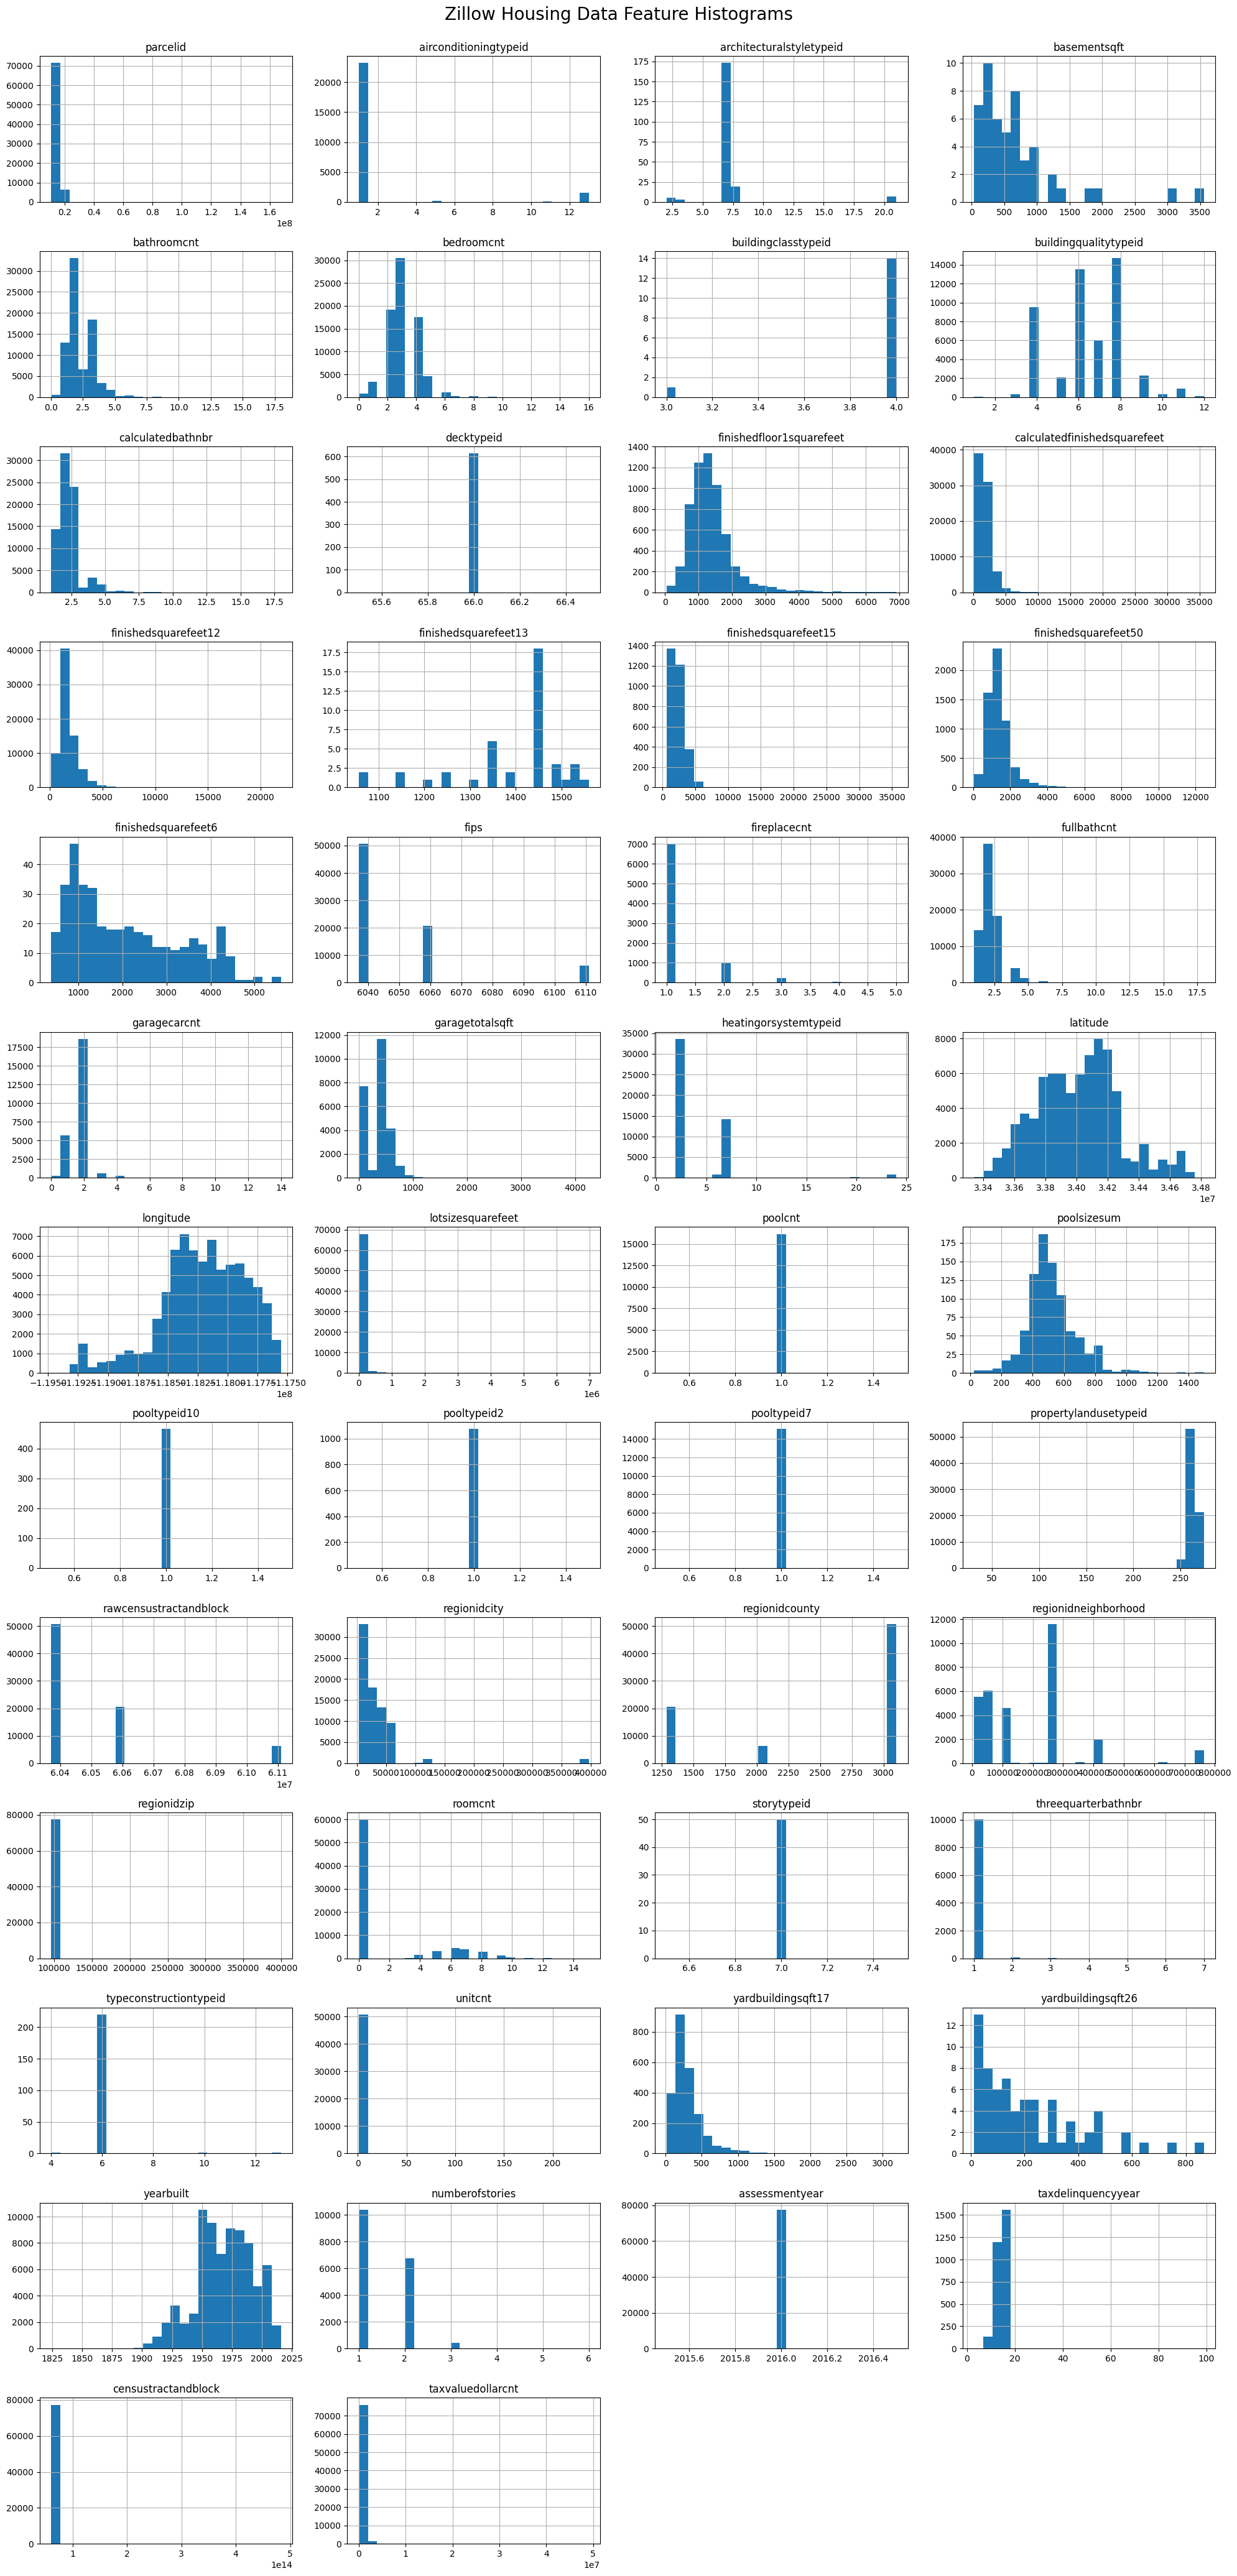

In [ ]:
# plot ALL - do not exclude categories with numeric values
df.hist(bins = 25, figsize = (20,45), layout = (14,4))
plt.suptitle("Zillow Housing Data Feature Histograms", fontsize=20)
plt.tight_layout(rect = [0, 0, 1, 0.98])

# reference: https://matplotlib.org/stable/users/explain/axes/tight_layout_guide.html

In [ ]:
# Generate individual visualizations for the target and three (3) additional features that you believe are particularly informative or interesting (a total of four features):
# Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
# Use as many code cells as you need, and give comments describing what each cell does.
# Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).

# pick three features that might be interesting to look at:  bathroomcnt,  bedroomcnt,  regionidneighborhood

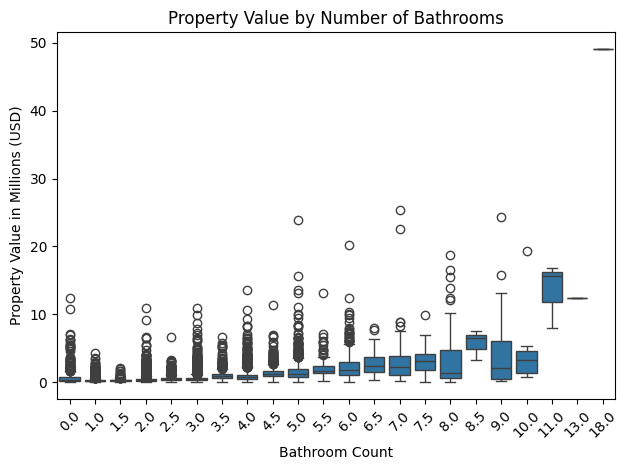

In [ ]:
# looking at the bathrooms
# sns.boxplot(data = df, x = "bathroomcnt", y = "taxvaluedollarcnt")
# plt.title("Relationship between Bathrooms and Property Value")
# plt.xlabel("Bathroom Count")
# plt.ylabel("Property Value (USD)")
# plt.xticks(rotation = 45)
# plt.tight_layout()

# outliers in each group, suggests something else may be driving the price (maybe location?)
# some properties have 18 bathrooms - may need to consider excluding

# decied to use the scaled version instead

# scale the property values and see if that improves the chart
df["target_scaled_millions"] = df["taxvaluedollarcnt"] / 1000000

sns.boxplot(data = df, x = "bathroomcnt", y = "target_scaled_millions")
plt.title("Property Value by Number of Bathrooms")
plt.xlabel("Bathroom Count")
plt.ylabel("Property Value in Millions (USD)")
plt.xticks(rotation = 45)
plt.tight_layout()

# used showfliers = False to not see outliers
# seems like there may be a relationship between bathroom count and property value (which is expected)

Text(0.5, 1.0, 'Number of Bathrooms')

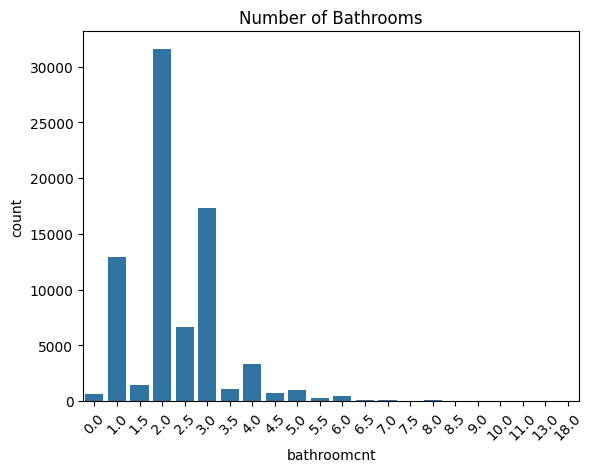

In [ ]:
# count plot of bathrooms
sns.countplot(df, x = "bathroomcnt")
plt.xticks(rotation = 45)
plt.title("Number of Bathrooms")

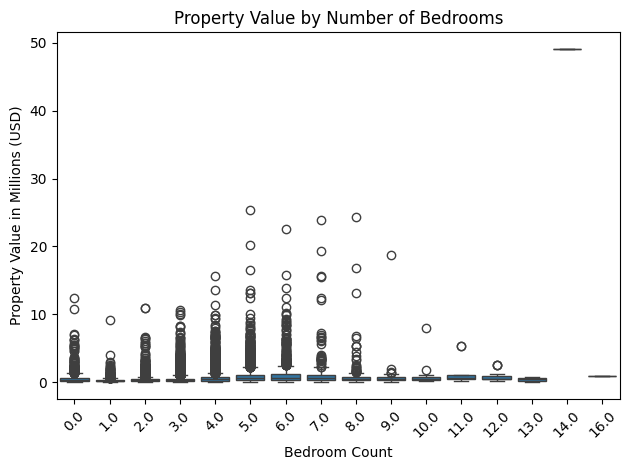

In [ ]:
# try bedrooms with scaled target
# moving on to bedrooms

sns.boxplot(data = df, x = "bedroomcnt", y = "target_scaled_millions")
plt.title("Property Value by Number of Bedrooms")
plt.xlabel("Bedroom Count")
plt.ylabel("Property Value in Millions (USD)")
plt.xticks(rotation = 45)
plt.tight_layout()

# not as clear a relationship as the bathrooms were
# still seems to be some positive relationship between bedrooms and value

Text(0.5, 1.0, 'Number of Bedrooms')

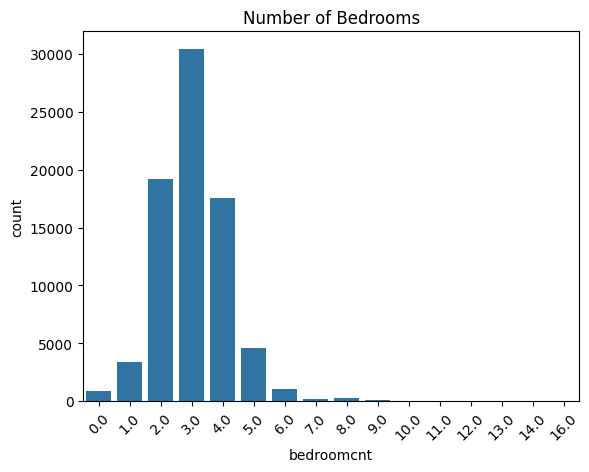

In [ ]:
# count plot of bedrooms
sns.countplot(df, x = "bedroomcnt")
plt.xticks(rotation = 45)
plt.title("Number of Bedrooms")

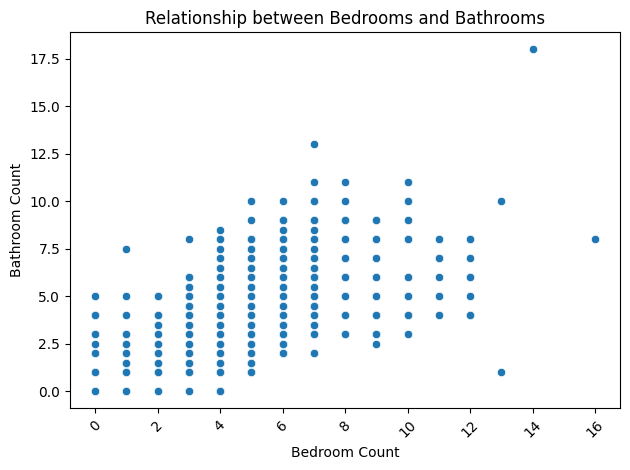

In [ ]:
# for curiosity's sake, I want to do a scatter of bathrooms and bedrooms
sns.scatterplot(data = df, x = "bedroomcnt", y = "bathroomcnt")
plt.title("Relationship between Bedrooms and Bathrooms")
plt.xlabel("Bedroom Count")
plt.ylabel("Bathroom Count")
plt.xticks(rotation = 45)
plt.tight_layout()

# looks like there's a property with 14 bedrooms and 18 bathrooms.. not sure this is correct
# many properties with 0 bathrooms also
# generally seems to be a positive relationship between the two


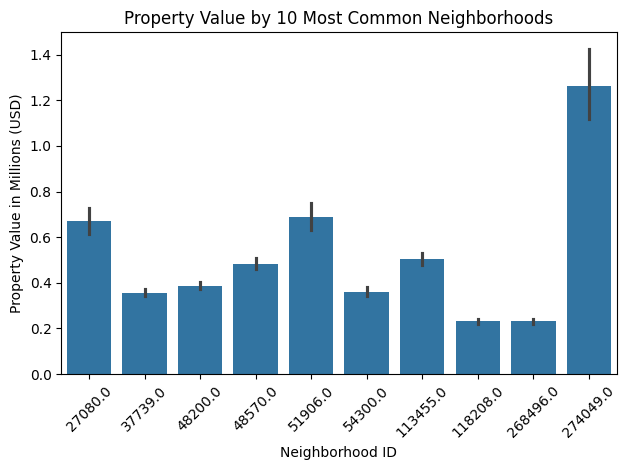

In [ ]:
# lastly looking at the regionidneighborhood which is categorical (wanted to mix things up!)
# want to show how many properties are in each neighborhood
# sns.countplot(df, x = "regionidneighborhood")

# too many IDs, very visually exhausting

# moved on to box plots

# sns.barplot(data = df, x = "regionidneighborhood", y = "taxvaluedollarcnt")
# plt.title("Relationship between Neighborhood and Property Value")
# plt.xlabel("Neighborhood ID")
# plt.ylabel("Property Value (USD)")
# plt.xticks(rotation = 45)
# plt.tight_layout()

# too many region IDs to be useful in one plot, going to limit to the most common 10 neighborhoods

top_neighborhood = df["regionidneighborhood"].value_counts().head(10).index
neighborhood_df = df[df["regionidneighborhood"].isin(top_neighborhood)].copy()
neighborhood_df["target_scaled_millions"] = neighborhood_df["taxvaluedollarcnt"] / 1000000

sns.barplot(data = neighborhood_df, x = "regionidneighborhood", y = "target_scaled_millions")
plt.title("Property Value by 10 Most Common Neighborhoods")
plt.xlabel("Neighborhood ID")
plt.ylabel("Property Value in Millions (USD)")
plt.xticks(rotation = 45)
plt.tight_layout()

# seeing that some neighborhoods do have higher property values than others
# definitely is a feature to look more into

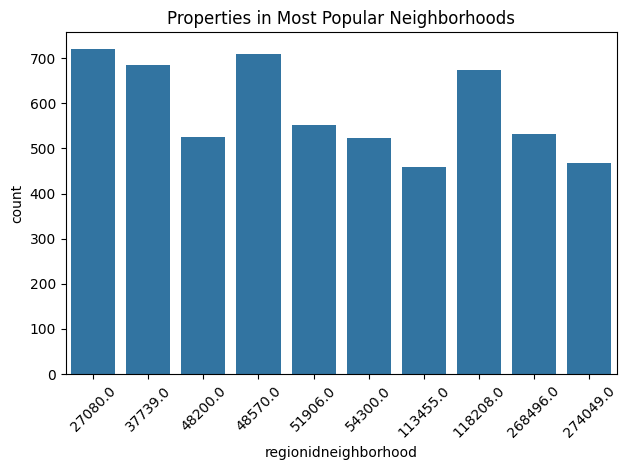

In [ ]:
# try the bar plot with the top 10 neighborhoods only
sns.countplot(neighborhood_df, x = "regionidneighborhood")
plt.xticks(rotation = 45)
plt.title("Properties in Most Popular Neighborhoods")
plt.tight_layout()

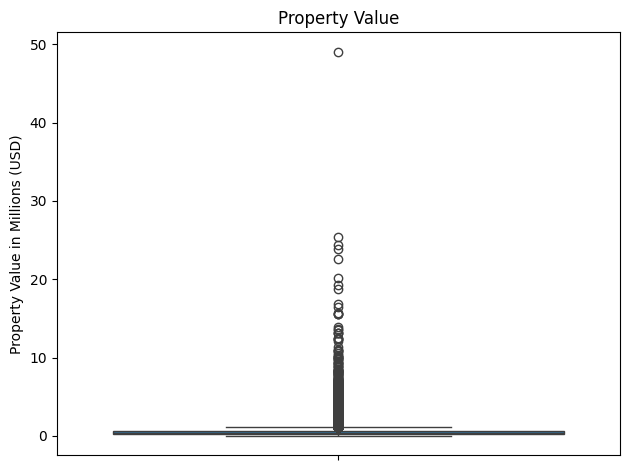

In [ ]:
# target plots
sns.boxplot(data = df, y = "target_scaled_millions")
plt.title("Property Value")
plt.ylabel("Property Value in Millions (USD)")
plt.xticks(rotation = 45)
plt.tight_layout()

# hard to read due to many outliers

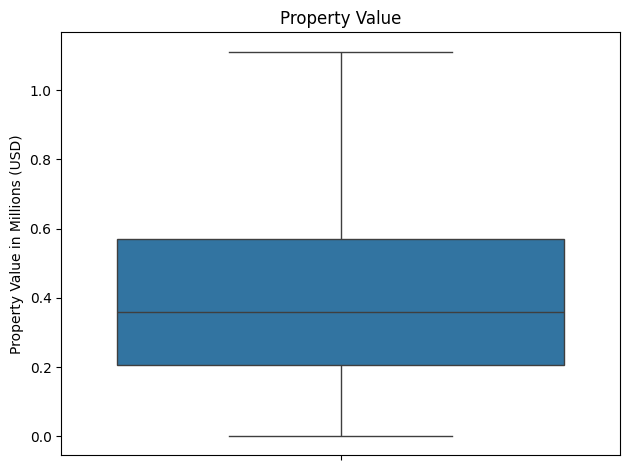

In [ ]:
# trying again without outliers to see if we can get a better view of it
sns.boxplot(data = df, y = "target_scaled_millions", showfliers = False)
plt.title("Property Value")
plt.ylabel("Property Value in Millions (USD)")
plt.xticks(rotation = 45)
plt.tight_layout()

#### **2.B Discussion:**

Describe what you learned from your detailed examination of the four features you selected. For each feature, discuss:

- The overall distribution (for example, approximately normal, skewed, or multimodal).
- Any notable characteristics, such as outliers, unusual values, or missing data.
- Why you selected the feature and what you learned about the dataset from examining it.

Conclude by briefly discussing whether any of the features you examined might require additional preprocessing later in the project (such as imputation, transformation, or outlier investigation).


> **Bathrooms**

The bathroom histogram showed multimodal peaks with a right skew due to some properties with many bathrooms. It also highlighted the many outliers in this feature; for example, one property has 18 bathrooms and another has 0. The boxplot showed many high-value properties within the bathroom count groups. Appears to be a positive relationship between bathrooms and property value. From personal experience, larger houses tend to have more bathrooms so I expected that this would impact property value. Learned that the vast majority of properties have 3 or less bathrooms.


> **Bedrooms**

The bedroom histogram is unimodal clustered around 2-4 bedrooms and has a right tail. High value outliers are seen in each group of the boxplot when compared to property value. Notably, there are also some properties without bedrooms - these may be studios, non-residential spaces, or missing values coded as 0. These edge cases would need to be reviewed individually. As it seems many of these properties are residential, it seemed logical to look into the number of bedrooms. I was surprised to see that bedrooms did not have as big a relationship with property value as bathrooms did.

> **Neighborhoods**

The colloquial phrase, "location, location, location!" guided my choice in investigating this feature. Due to the sheer number of neighborhoods, I isolated properties within the 10 most common neighborhoods. The distribution was fairly balanced with all the neighborhoods having between ~400-~700 properties accounted for. Looking at those same neighborhoods, there is high variation in average property value - ranging from ~200k to ~1.2 million. This suggests that the neighborhood may be useful for our predictions. Unfortunately, this column is also missing about 60% of its data, but I do think it may still be meaningful data.

> **Target**

The target's histogram had a very heavy right skew concentrating around lower property values. The box plot helped to emphasize the outliers in property value - one property stands above the rest at nearly 50 million. When outliers were hidden for visualization, the middle 50% of properties fell within the range of 200k - 570k. There are some missing values that will likely be dropped. I'm curious to dive deeper into the data to see what may be driving the heavy presence of outliers - location maybe?


> **Conclusions**

Depending on the business goal, it may be worth it to investigate certain outliers ($50 million property or those without bathrooms) to determine how they should be handled (keep, drop, or transform). I scaled the target value to make plots more interpretable, this may be good to use in future plots. As the target is heavily skewed a log transformation may also be appropriate. For the neighborhood, one hot encoding may be best but I would be concerned over the computational cost given how many unique IDs are present in this feature. We could consider grouping neighborhoods or other encoding strategies

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts] - Lauriston



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task!

In [ ]:
#selecting the features that should be removed and removing them
features_useless = [
    'parcelid',
    'assessmentyear',
    'fips',
    'rawcensustractandblock',
    'fullbathcnt',
    'threequarterbathnbr',
    'finishedfloor1squarefeet',
    'finishedsquarefeet12',
    'finishedsquarefeet13',
    'finishedsquarefeet15',
    'finishedsquarefeet50',
    'finishedsquarefeet6',
    'basementsqft',
    'yardbuildingsqft17',
    'yardbuildingsqft26',
    'poolsizesum',
    'pooltypeid10',
    'pooltypeid2',
    'pooltypeid7',
    'fireplaceflag',
]


df_3a = df.drop(columns=features_useless)


#### **3.A Discussion:**

Describe the features you chose to remove, if any, and justify each decision. For each feature, explain:

- Why you believed it was unsuitable for predicting the target.
- Which characteristic led to your decision (for example, an identifier, irrelevant information, or another reason).
- Why your decision was based on the feature's meaning rather than the amount of missing data.

If you chose not to remove any features, explain why.

> The features removed in this part are the same ones that were determined to be useless for this project in part 2.A.2.


**Useless features**  
parcelid is only good for identification not preditions.
assessmentyear is contains data only from 2016, making it out dated for future predictoins.


**Redundant features**  
flips    
rawcensustractandblock  

flips is too similar to regionidcounty
rawcensustractandblock is the raw data version of censustractandblock
fullbathcnt and threequarterbathnbr are likely to have overlapping data for bathrooms with other features like Bathroomcnt.


**Square footage**  
finishedfloor1squarefeet  
finishedsquarefeet12  
finishedsquarefeet13  
finishedsquarefeet15  
finishedsquarefeet50  
finishedsquarefeet6  
basementsqft  
yardbuildingsqft17  
yardbuildingsqft26  

Each of these features desribe overlapping meauress of finished area. There is no need for multiple of these when a few can do the job.


**Pools**  
poolsizesum  
pooltypeid10  
pooltypeid2  
pooltypeid7  

Each of these pool features carry redudent information of the same pool.


**Fireplaces**  
fireplaceflag

fireplaceflag is only an indication if there is a fireplace while fireplacecnt give information on how many there are.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully.

In [ ]:
#finding the amount and percentages of null values
missing = df_3a.isnull().sum()
pct = (missing / len(df_3a)) * 100
report = pd.DataFrame({'missing_count': missing, 'missing_pct': pct})
final_report = report[report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(final_report)

                              missing_count  missing_pct
buildingclasstypeid                   77598    99.980673
storytypeid                           77563    99.935578
architecturalstyletypeid              77406    99.733292
typeconstructiontypeid                77390    99.712677
decktypeid                            76999    99.208895
hashottuborspa                        76074    98.017085
taxdelinquencyflag                    74713    96.263513
taxdelinquencyyear                    74713    96.263513
fireplacecnt                          69324    89.320088
poolcnt                               61439    79.160708
numberofstories                       60014    77.324675
airconditioningtypeid                 52606    67.779882
garagetotalsqft                       52093    67.118910
garagecarcnt                          52093    67.118910
regionidneighborhood                  46639    60.091737
heatingorsystemtypeid                 28042    36.130545
buildingqualitytypeid          

In [ ]:
#removing the features with more than 60% missing values with a few exceptions.
missing = df_3a.isnull().mean()
drop = missing[missing > 0.6].index.tolist()
drop.remove('fireplacecnt')
drop.remove('poolcnt')
drop.remove('taxdelinquencyflag')

removed = missing[missing > 0.6].sort_values(ascending=False)
df_3b = df_3a.drop(columns=drop)

print(df_3b.columns)


Index(['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid',
       'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'fireplacecnt',
       'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet',
       'poolcnt', 'propertycountylandusecode', 'propertylandusetypeid',
       'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidzip',
       'roomcnt', 'unitcnt', 'yearbuilt', 'taxdelinquencyflag',
       'censustractandblock', 'taxvaluedollarcnt', 'target_scaled_millions'],
      dtype='object')


#### **3.B Discussion:**

Describe the criteria you used to decide which features had **too many** missing values to retain.

In particular, explain:

- The threshold you selected for determining when a feature should be removed.
- Why you believe this threshold was appropriate for this dataset.
- Whether you considered the usefulness of the remaining non-null values before deciding to remove a feature, and how this influenced your decision.

> Our dataset has a few features with 60% or more null values. Missing data has no use when we need to predict based off of it. With a drop off from 60% null to 36% null, we think that 60% is a good threshold to remove unneeded features barring the few exemptions. Only a select few were keep in that range because of the benefit they provide. For example, the fireplacecnt was keep despite missing over 89% of its values because of the value it provides.

### Part 3.C: Remove Problematic Samples

Some samples may not be suitable for model training because they contain insufficient information or cannot be used for supervised learning.

- Remove any sample with a missing target value.
- Decide on a reasonable threshold for the maximum percentage of missing feature values in a sample, justify your choice, and remove samples exceeding that threshold.
- Investigate whether the dataset contains potential outliers, but **do not remove them yet.** Instead, describe how you identified them and explain why removing them may or may not be appropriate. Their effect on model performance will be investigated in Milestone 2.

Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [ ]:
target = 'taxvaluedollarcnt'

#removing all rows with missing taxvaluedollarcnt
df_3c = df_3b.dropna(subset=[target])

#finding the percentiles of missing values
missing_fra = df_3c.isnull().mean(axis=1)
print((missing_fra * 100).describe())

#removing rows with more than 25% missing features
df_3c = df_3c[missing_fra <= 0.25]


#Finding the potential outliers
num_cols = df_3c.select_dtypes(include='number').columns.drop(target)

for col in num_cols:
    q1, q3 = df_3c[col].quantile([0.25,0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df_3c[col] < lower) | (df_3c[col] > upper)).sum()
    if n_outliers > 0:
        pct = 100 * n_outliers / len(df_3c)
        print(f"{col} {n_outliers:>10} outliers ({pct:.2f}%)")

count    77578.000000
mean        17.522096
std          8.341965
min          4.166667
25%         12.500000
50%         12.500000
75%         25.000000
max         54.166667
dtype: float64
bathroomcnt       1998 outliers (3.28%)
bedroomcnt        381 outliers (0.62%)
buildingqualitytypeid        150 outliers (0.25%)
calculatedbathnbr       1883 outliers (3.09%)
calculatedfinishedsquarefeet       3196 outliers (5.24%)
fireplacecnt       1212 outliers (1.99%)
heatingorsystemtypeid        141 outliers (0.23%)
latitude       2235 outliers (3.67%)
longitude       1751 outliers (2.87%)
lotsizesquarefeet       9875 outliers (16.20%)
propertylandusetypeid      17368 outliers (28.49%)
regionidcity       2140 outliers (3.51%)
regionidcounty      10369 outliers (17.01%)
regionidzip       7932 outliers (13.01%)
roomcnt       9342 outliers (15.32%)
unitcnt       3038 outliers (4.98%)
yearbuilt         72 outliers (0.12%)
censustractandblock      10377 outliers (17.02%)
target_scaled_millions     

#### **3.C Discussion:**

Describe your decisions about which samples were removed and why.

In particular, discuss:

- The criteria you used to identify samples that should be removed (for example, missing target values or excessive missing data).
- If you identified potential outliers, explain how you identified them and why you chose to retain them at this stage.
- The potential advantages and disadvantages of removing outliers, and why you believe this decision should be evaluated experimentally in **Milestone 2**.

> The first criteria for samples to removed were the samples that did not have a taxvaluedollarcnt. After removing them we found the the mean, std, and percentiles of missing data from each row. We dermined that any more than 25 % missing values was a good number because it would remove less than 25% of the samples with the most missing features. When it comes to removing outliers, there are some benefits including allowing the RMSE to be more stable with less outliers. The downside is that we would be throwing out valueble data for a section of the housing market. It should be testing and evaluated later on.

### Part 3.D: Split the Dataset into Training and Test Sets

Now that the initial data cleaning is complete, split the dataset into training and test sets.

Use:

- test_size=0.20
- random_state=42

The remaining preprocessing steps should be learned **only from the training set** and then applied unchanged to the test set. This prevents information from the test set from influencing the training process ("data leakage").

No discussion necessary.

In [ ]:
target = 'taxvaluedollarcnt'

X = df_3c.drop(columns=[target,"target_scaled_millions"])
y = df_3c[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=random_state
)

In [ ]:
# becka added: drop feature "target_scaled_millions" from part 2 to avoid data leakage - instead removing from X
# df_3a = df_3a.drop(columns=["target_scaled_millions"])
# df_3b = df_3b.drop(columns=["target_scaled_millions"])
# df_3c = df_3c.drop(columns=["target_scaled_millions"])

In [ ]:
print("3a columns:", df_3a.columns)
print("3b columns:", df_3b.columns)
print("3c columns:", df_3c.columns)
print("X", X.columns)

3a columns: Index(['airconditioningtypeid', 'architecturalstyletypeid', 'bathroomcnt',
       'bedroomcnt', 'buildingclasstypeid', 'buildingqualitytypeid',
       'calculatedbathnbr', 'decktypeid', 'calculatedfinishedsquarefeet',
       'fireplacecnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa',
       'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet',
       'poolcnt', 'propertycountylandusecode', 'propertylandusetypeid',
       'propertyzoningdesc', 'regionidcity', 'regionidcounty',
       'regionidneighborhood', 'regionidzip', 'roomcnt', 'storytypeid',
       'typeconstructiontypeid', 'unitcnt', 'yearbuilt', 'numberofstories',
       'taxdelinquencyflag', 'taxdelinquencyyear', 'censustractandblock',
       'taxvaluedollarcnt', 'target_scaled_millions'],
      dtype='object')
3b columns: Index(['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid',
       'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'fireplacecnt',
       'heatingorsystemtypeid', '

### Part 3.E: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Fit your imputation method(s) using only the training data.
- Apply the fitted imputer(s) to both the training and test sets so that no missing values remain.
- Answer the discussion question.


In [ ]:
#selecting the proper columns for each category
numeric_cols = list(X_train.select_dtypes(include='number').columns)
categorical_cols = list(X_train.select_dtypes(exclude='number').columns)

#tried moving all ids into the categorical col, however some were unable to be moved
cols_to_move = ["airconditioningtypeid","architecturalstyletypeid","buildingclasstypeid",
               "decktypeid","regionidcity","propertylandusetypeid","storytypeid","typeconstructiontypeid","regionidcounty"]
cols_to_move = [c for c in cols_to_move if c in X_train.columns]

numeric_cols = [c for c in numeric_cols if c not in cols_to_move]
categorical_cols += cols_to_move

# checking the skewness of the numeric columns
skew = X_train[numeric_cols].skew()
skew_threshold = 0.5
skewed_cols = skew[skew.abs() > skew_threshold].index.tolist()
norm_cols = [c for c in numeric_cols if c not in skewed_cols]

# completing the median imputation for numeric columns
X_train_num = X_train[numeric_cols].copy()
X_test_num = X_test[numeric_cols].copy()

# impuatation for the skewed columns
median_imputer = SimpleImputer(strategy='median')
median_imputer.fit(X_train[skewed_cols])
X_train_num[skewed_cols] = median_imputer.transform(X_train[skewed_cols])
X_test_num[skewed_cols] = median_imputer.transform(X_test[skewed_cols])

# impuatation for the norm columns
norm_imputer = SimpleImputer(strategy='median')
norm_imputer.fit(X_train[norm_cols])
X_train_num[norm_cols] = norm_imputer.transform(X_train[norm_cols])
X_test_num[norm_cols] = norm_imputer.transform(X_test[norm_cols])
mode_col = [c for c in categorical_cols]

# completing the mode impuatation for categorical columns
X_train_cat = X_train[categorical_cols].copy()
X_test_cat = X_test[categorical_cols].copy()


mode_imputer = SimpleImputer(strategy='most_frequent')
mode_imputer.fit(X_train[mode_col])
X_train_cat[mode_col] = mode_imputer.transform(X_train[mode_col])
X_test_cat[mode_col] = mode_imputer.transform(X_test[mode_col])



X_train_3e = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_3e = pd.concat([X_test_num, X_test_cat], axis=1)


In [ ]:
print(numeric_cols)

Index(['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid',
       'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'fireplacecnt',
       'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet',
       'poolcnt', 'propertylandusetypeid', 'regionidcity', 'regionidcounty',
       'regionidzip', 'roomcnt', 'unitcnt', 'yearbuilt',
       'censustractandblock'],
      dtype='object')


In [ ]:
print(categorical_cols)

Index(['propertycountylandusecode', 'propertyzoningdesc',
       'taxdelinquencyflag'],
      dtype='object')


In [ ]:
print(df_3c['taxdelinquencyflag'].unique())

[nan 'Y']


#### **3.E Discussion:**

Describe your overall imputation strategy.

In particular, explain:

- Which imputation method(s) you selected.
- Why each method was appropriate for the feature(s) to which it was applied.
- Whether you used different strategies for different types of features (for example, numerical versus categorical, or approximately normal versus skewed numerical features), and why.

> The imputation methods that were selected were the median imputation for numerical values and mode imputation for categorical values. The median was appropriate because the values are skewed from so many outliers. This is where the median imputation would come in and be the best fit for filling in values as close to accurate as possible. For the mode imputation in the categorical columns, the most common was chosen as a replacement. This allowed for the models to work with data as close as possible to what is expected, with out add any other value. We may need to consider encoding poolcnt and fireplacecnt with 0 instead of the median as that may skew the imputation to indicating all these properties have a pool/fireplace.

### 3.F: Encode the Categorical Features (if any)

Refer to Appendix 3 for a summary of feature types and appropriate encoding strategies.

- Identify any categorical features that remain after your earlier preprocessing. For each feature, determine whether it is nominal or ordinal, then choose an appropriate encoding method. Use ordinal encoding only for features with a meaningful ordering, and one-hot encoding for nominal features with no natural ordering.

- Fit the encoder(s) using only the training data, then apply the fitted encoder(s) to both the training and test sets. Some teams may have very few categorical features remaining after the earlier cleaning steps.

**Note:** Many categorical features in this dataset are represented by numeric identifier codes (for example, `propertylandusetypeid`). Do not assume that a feature is numerical simply because its data type is int or float. Instead, use the feature descriptions in Appendix 1 and flowchart in Appendix 3 to determine whether the feature represents a numerical measurement or a categorical variable.

In [ ]:
#placing all features into their correct feature list
ordinal_features = [ 'buildingqualitytypeid','hashottuborspa','taxdelinquencyflag']

nominal_features = [
    "parcelid",
    "airconditioningtypeid",
    "architecturalstyletypeid",
    "buildingclasstypeid",
    "decktypeid",
    "fips",
    "heatingorsystemtypeid",
    "propertycountylandusecode",
    "propertylandusetypeid",
    "propertyzoningdesc",
    "rawcensustractandblock",
    "regionidcity",
    "regionidcounty",
    "regionidneighborhood",
    "regionidzip",
    "storytypeid",
    "typeconstructiontypeid",
    "censustractandblock"
]

#sorting out the features used vs unused
ordinal_features = [c for c in ordinal_features if c in X_train_3e.columns]
nominal_features = [c for c in nominal_features if c in X_train_3e.columns]

print("Ordinal features:", ordinal_features)
print("Nominal features:", nominal_features)

#encoding of ordinal features
ordinal_encoder = OrdinalEncoder()
ordinal_encoder.fit(X_train_3e[ordinal_features])
X_train_ord = pd.DataFrame(
    ordinal_encoder.transform(X_train_3e[ordinal_features]),
    columns=ordinal_features, index=X_train_3e.index
)

X_test_or = pd.DataFrame(
    ordinal_encoder.transform(X_test_3e[ordinal_features]),
    columns=ordinal_features, index=X_test_3e.index
)
#one-hot encoding for nominal features
X_train_nom = pd.get_dummies(X_train_3e[nominal_features].astype(str), prefix=nominal_features)
X_test_nom = pd.get_dummies(X_test_3e[nominal_features].astype(str), prefix=nominal_features)
X_test_nom = X_test_nom.reindex(columns=X_train_nom.columns, fill_value=0)

#creating the remaining columns list
encoded_cols = ordinal_features + nominal_features
remaining_cols = [c for c in X_train_3e.columns if c not in encoded_cols]

X_train_3f = pd.concat([X_train_3e[remaining_cols], X_train_ord, X_train_nom], axis=1)
X_test_3f = pd.concat([X_test_3e[remaining_cols], X_test_or, X_test_nom], axis=1)

Ordinal features: ['buildingqualitytypeid', 'taxdelinquencyflag']
Nominal features: ['heatingorsystemtypeid', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidzip', 'censustractandblock']


#### **3.F Discussion:**

Describe the categorical features that remained after your earlier preprocessing.

In particular, discuss:

- Which features you identified as categorical.
- Whether each feature is **nominal** or **ordinal**, and why.
- The encoding method you selected for each feature and why it was appropriate.
- At least one feature that is represented by a numeric identifier rather than text, explaining why it is still categorical and how this influenced your encoding decision.

> Ordinal and nominal categories were to tow groups of categorical features chosen. buildingqualitytypeid was classified as ordinal because it is a quility rating. The rest were treated as nominal because there were no specific inherent order to them. All of the ordinal features were encoded with OrdinalEncoder to maintain their order, while nominal features used one-hot enconding (pd.get_dummies). propertylandusetpeid is a good example of a numeric identifier that is categorical. It categorical even though it is stored as an integer because the ID codes reperesent property use types. If the ID was treated as a continuous value, the model would end up being mislead and may assume false ordinal relationships.

## Part 4: Investigate Feature Relationships [6 pts] - Becka

In this part, you will investigate relationships among the features and between the features and the target. The goal is to better understand the dataset and identify opportunities for future feature engineering.

**Important:** At this stage, you should **not** commit to any changes to the dataset based on these analyses. Many preprocessing and feature engineering decisions are model-dependent and will be evaluated experimentally in **Milestone 2**.

### Part 4.A: Correlation and Feature Importance

Investigate relationships among the features and between the features and the target.

In the next cell(s):

- Compute a **correlation matrix** for the numerical features.
- Visualize the results where appropriate (for example, a heatmap and a bar chart).
- Identify features that appear to have particularly strong or weak relationships with the target.
- Identify pairs of features that appear to be highly correlated.
- Do **not** remove or transform any features based on these analyses.

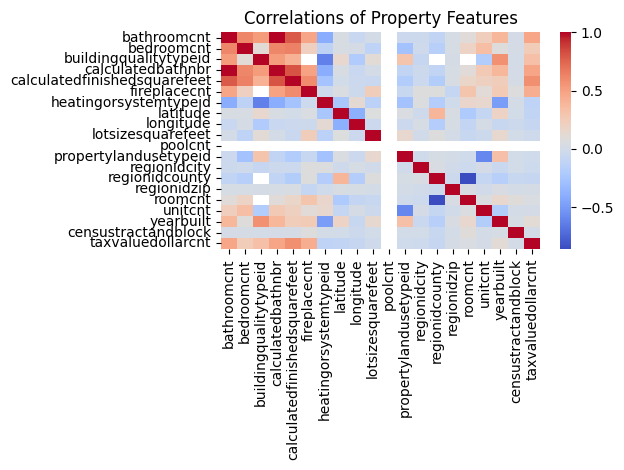

In [ ]:
# start with a correlation matrix
corr = df_3c.corr(numeric_only=True)
corr = corr.drop(columns = ["target_scaled_millions"])
corr = corr.drop(index = ["target_scaled_millions"])

# need to drop features that are numeric appearing
# corr = corr.drop(columns = ['parcelid','rawcensustractandblock', 'regionidcity',
#                             'regionidcounty', 'regionidzip', 'propertylandusetypeid',
#                             'assessmentyear', 'fips', 'censustractandblock', 'heatingorsystemtypeid'])
# corr = corr.drop(index = ['parcelid','rawcensustractandblock', 'regionidcity',
#                             'regionidcounty', 'regionidzip', 'propertylandusetypeid',
#                             'assessmentyear', 'fips', 'censustractandblock', 'heatingorsystemtypeid'])
# print(corr.columns)
# Index(['parcelid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid',
#        'calculatedbathnbr', 'calculatedfinishedsquarefeet',
#        'finishedsquarefeet12', 'fips', 'fireplacecnt', 'fullbathcnt',
#        'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet',
#        'poolcnt', 'propertylandusetypeid', 'rawcensustractandblock',
#        'regionidcity', 'regionidcounty', 'regionidzip', 'roomcnt', 'unitcnt',
#        'yearbuilt', 'assessmentyear', 'censustractandblock',
#        'taxvaluedollarcnt'],


sns.heatmap(corr, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("Correlations of Property Features")
plt.tight_layout()

# it's a good start, but too many variables to view easily, want to try a more targeted version

# identify some feature pairings to look deeper into
# bedroom and bathrooms
# fireplace and calculatedfinishedsquarefeet
# lattitude and longitude (makes sense)
# bedroom and calculatedfinishedsquarefeet
# bathroom and calculatedfinishedsquarefeet



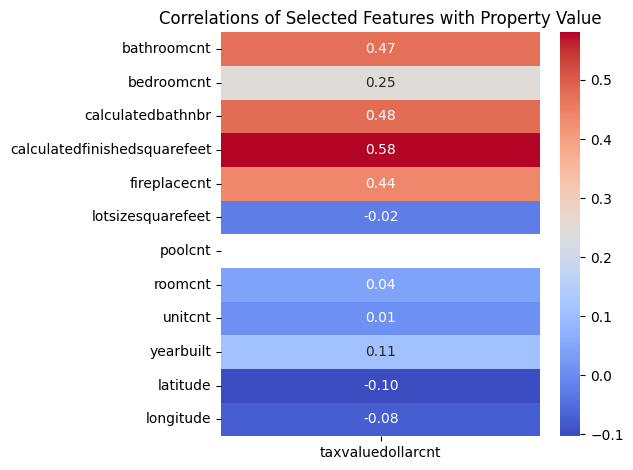

In [ ]:
# more targeted heatmap
# print(corr.columns)
# ['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid',
#        'calculatedbathnbr', 'calculatedfinishedsquarefeet',
#        'finishedsquarefeet12', 'fireplacecnt', 'fullbathcnt', 'latitude',
#        'longitude', 'lotsizesquarefeet', 'poolcnt', 'roomcnt', 'unitcnt',
#        'yearbuilt', 'taxvaluedollarcnt'],
corr_features = ['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'fireplacecnt','lotsizesquarefeet', 'poolcnt', 'roomcnt', 'unitcnt',
       'yearbuilt', 'taxvaluedollarcnt', 'latitude','longitude']

corr_target = df_3c[corr_features].corr(numeric_only=True)[["taxvaluedollarcnt"]]
corr_target = corr_target.drop(index ="taxvaluedollarcnt")

sns.heatmap(corr_target, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlations of Selected Features with Property Value")
plt.tight_layout()

# top strong correlations:
# 'finishedsquarefeet12' 0.61 - removed (accidentally included in df_3c)
# 'calculatedfinishedsquarefeet'0.58
# 'calculatedbathnbr' 0.48
# 'bathroomcnt' 0.47
# 'fullbathcnt' 0.47 - removed (accidentally included in df_3c)
# 'fireplacecnt' .44

# top weak correlations
# 'poolcnt' did not calculate due to no numeric variation
# 'roomcnt' 0.04
# 'unitcnt' 0.01
# 'lotsizesquarefeet' -0.02

# kind of surprising that bedrooms have such a weak correlation 0.25

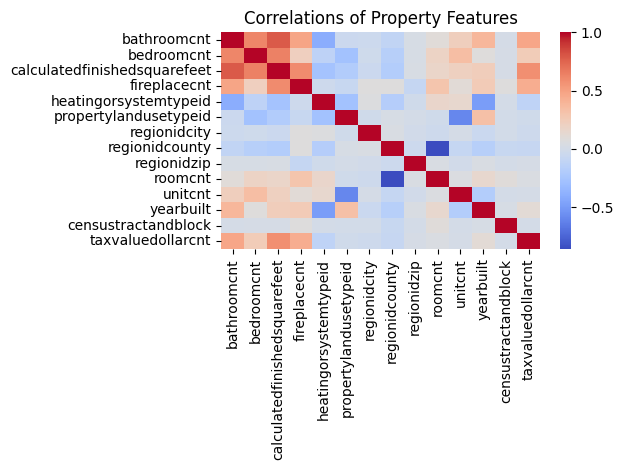

In [ ]:
# going to look deeper into specific relationships now
# bedroom and bathrooms
# fireplace and finishedsquarefeet12
# lattitude and longitude (makes sense)
# bedroom and calculatedfinishedsquarefeet
# bathroom and calculatedfinishedsquarefeet

# need to drop features that we don't care about
corr2 = corr.drop(columns = ['buildingqualitytypeid','calculatedbathnbr', 'latitude',
                            'longitude', 'lotsizesquarefeet', 'poolcnt' ])
corr2 = corr2.drop(index = ['buildingqualitytypeid','calculatedbathnbr', 'latitude',
                            'longitude', 'lotsizesquarefeet', 'poolcnt'])
# print(corr.columns)
# ['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid',
#        'calculatedbathnbr', 'calculatedfinishedsquarefeet',
#        'finishedsquarefeet12', 'fireplacecnt', 'fullbathcnt', 'latitude',
#        'longitude', 'lotsizesquarefeet', 'poolcnt', 'roomcnt', 'unitcnt',
#        'yearbuilt', 'taxvaluedollarcnt']


sns.heatmap(corr2, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("Correlations of Property Features")
plt.tight_layout()

# some obvious correlations:
  # bathrooms correlated with other bathroom features
  # sqrft features correlated with other sqrft features
  # bathrooms, bedrooms, and square feet all correlated (makes sense since bathrooms and bedrooms contribute to size)

# other correlations
  # fireplaces are positive correlated with square footage
  # target's strongest correlations are with: sqrft, bath, bed, and fireplace

Text(0.5, 1.0, 'Property Value in Millions by Bedrooms and Bathrooms')

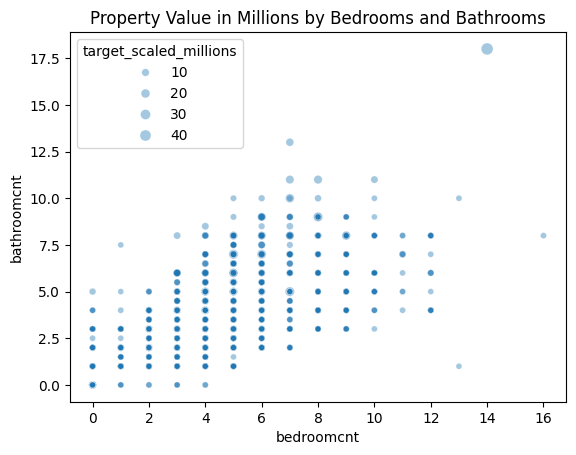

In [ ]:
# want to look at the relationship of bedrooms and bathrooms on the target via bubble plot

sns.scatterplot(data = df_3c, x = 'bedroomcnt', y = 'bathroomcnt', size = "target_scaled_millions", alpha = 0.4)
plt.title("Property Value in Millions by Bedrooms and Bathrooms")

In [ ]:
# strongest correlations with the target
print(corr["taxvaluedollarcnt"].sort_values(ascending=False))

taxvaluedollarcnt               1.000000
calculatedfinishedsquarefeet    0.580698
calculatedbathnbr               0.478793
bathroomcnt                     0.472642
fireplacecnt                    0.438783
buildingqualitytypeid           0.327872
bedroomcnt                      0.246191
yearbuilt                       0.108015
roomcnt                         0.042502
regionidzip                     0.016105
unitcnt                         0.007273
censustractandblock             0.005166
propertylandusetypeid          -0.019721
lotsizesquarefeet              -0.023993
regionidcity                   -0.032826
regionidcounty                 -0.074197
longitude                      -0.075163
latitude                       -0.103478
heatingorsystemtypeid          -0.122515
poolcnt                              NaN
Name: taxvaluedollarcnt, dtype: float64


In [ ]:
# highly correlated features

# set a threshold for highly correlated
corr_thresh = 0.5

# find the feature pairs
for i in range (len(corr.columns)):
  for j in range (i + 1, len(corr.columns)):
    feature_1 = corr.columns[i]
    feature_2 = corr.columns[j]
    corr_value = corr.iloc[i,j]

    if abs(corr_value) >= corr_thresh:
      print(feature_1, "and", feature_2, "correlation:", round(corr_value, 2))


bathroomcnt and bedroomcnt correlation: 0.62
bathroomcnt and buildingqualitytypeid correlation: 0.52
bathroomcnt and calculatedbathnbr correlation: 1.0
bathroomcnt and calculatedfinishedsquarefeet correlation: 0.79
bedroomcnt and calculatedbathnbr correlation: 0.62
bedroomcnt and calculatedfinishedsquarefeet correlation: 0.64
buildingqualitytypeid and calculatedbathnbr correlation: 0.52
buildingqualitytypeid and heatingorsystemtypeid correlation: -0.63
buildingqualitytypeid and yearbuilt correlation: 0.57
calculatedbathnbr and calculatedfinishedsquarefeet correlation: 0.81
calculatedfinishedsquarefeet and fireplacecnt correlation: 0.6
calculatedfinishedsquarefeet and taxvaluedollarcnt correlation: 0.58
propertylandusetypeid and unitcnt correlation: -0.6
regionidcounty and roomcnt correlation: -0.86


In [ ]:
# F stats (not included in instructions, but in the 4A discussion)

# numeric cols only, drop target/categorical & set variables

target_fstats = "taxvaluedollarcnt"
X_fstats = df_3c.select_dtypes(include="number").copy()
X_fstats = X_fstats.drop(columns=[target_fstats, "target_scaled_millions", "buildingqualitytypeid", "heatingorsystemtypeid", "regionidcounty", "regionidcity", "propertylandusetypeid", "regionidzip", "censustractandblock"])

y_fstats = df_3c[target_fstats]

# check for missing values in X_fstats
X_fstats.isna().sum().sort_values(ascending=False)
# many missing values - need to impute

imputer_fstats = SimpleImputer(strategy = "median")
X_f_imputed = imputer_fstats.fit_transform(X_fstats)

# get the f stats now
f_scores, p_values = f_regression(X_f_imputed, y_fstats)

f_results = pd.DataFrame({"Feature": X_fstats.columns, "F-Stats": f_scores, "p-value": p_values})
f_results = f_results.sort_values(by = "F-Stats", ascending = False)
f_results

# looks like some of these results are actually categorical so I dropped them and re-ran


,Feature,F-Stats,p-value
3,calculatedfinishedsquarefeet,31012.724157,0.000000e+00
2,calculatedbathnbr,17857.619244,0.000000e+00
0,bathroomcnt,17536.202716,0.000000e+00
1,bedroomcnt,3933.444283,0.000000e+00
11,yearbuilt,719.400364,1.493181e-157
4,fireplacecnt,679.447363,5.802611e-149
5,latitude,659.849481,9.534101e-145
6,longitude,346.373021,4.276295e-77
9,roomcnt,110.326734,8.742697e-26
7,lotsizesquarefeet,34.652296,3.962297e-09


#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to be the strongest predictors of the target.
- Which pairs of features appeared to be highly correlated.
- Whether the correlation matrix and the F-statistics led you to similar conclusions about the most important features. Explain your reasoning.

> Strongest predictors of the target

Based on correlations, the features with the strongest relationships to the target are:
*   calculatedfinishedsquarefeet (0.580698)
*   calculatedbathnbr (0.478793)
*   bathroomcnt (0.472642)
*   fireplacecnt (0.438783)

> Highly correlated features
The most highly correlated features, based on threshold abs(0.5) are:
*   bathroomcnt and bedroomcnt correlation: 0.62
*   bathroomcnt and calculatedbathnbr correlation: 1.0
*   bathroomcnt and calculatedfinishedsquarefeet correlation: 0.79
*   bedroomcnt and calculatedbathnbr correlation: 0.62
*   bedroomcnt and calculatedfinishedsquarefeet correlation: 0.64
*   calculatedbathnbr and calculatedfinishedsquarefeet correlation: 0.81
*   calculatedfinishedsquarefeet and fireplacecnt correlation: 0.6

These show a clear trend of bathrooms, bedrooms, square footage, and fireplaces being correlated as they all relate to property size.


> Correlation / F-stats led to similar conclusions?

(4 AInstructions did not ask for F-stats, only the discussion did)

As the dataset was very large, many features had incredibly small p-values. Due to this, we found the f-statistics more useful to determine feature importance. The F-stats had similar results to the correlations with the top features being: calculatedfinishedsquarefeet,calculatedbathnbr, and bathroomcnt. All 3 of those top features also had strong correlations with the target. Bedroom count did not have a particularly high corrrelation with the target, but was near the top of the features in the f-stats.

index	Feature	F-Stats	p-value
*   3	calculatedfinishedsquarefeet	31012.724157	0.000000e+00
*   2	calculatedbathnbr	17857.619244	0.000000e+00
*   0	bathroomcnt	17536.202716	0.000000e+00
*   1	bedroomcnt	3933.444283	0.000000e+00
*   11	yearbuilt	719.400364	1.493181e-157
*   4	fireplacecnt	679.447363	5.802611e-149
*   5	latitude	659.849481	9.534101e-145
*   6	longitude	346.373021	4.276295e-77
*   9	roomcnt	110.326734	8.742697e-26
*   7	lotsizesquarefeet	34.652296	3.962297e-09
*   10	unitcnt	0.039419	8.426212e-01
*   8	poolcnt	0.000000	1.000000e+00

#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to have the strongest relationships with the target.
- Which pairs of features appeared to be highly correlated.
- Whether any relationships suggest opportunities for future feature engineering or preprocessing in Milestone 2.

> See above for first two answers

> Feature engineering / preprocessing

bathroomcnt and calculatedbathnbr were highly correlated, due to their redundancy we would likely pick one of them to drop during pre-processing. The target value was right-skewed and may benefit from a log transformation. Additionally, we may need to approach features like poolcnt and fireplacecnt differently in pre-processing. Imputing them with the median is unlikely to be useful as there are only two unique values (0/1) and that may misleadingly skew these features.

Some of the relationships would also be worth exploring through feature engineering. Bathrooms were one of the most strongly correlated features with the target, but surprisingly bedrooms did not show a similar relationship. It would be interesting to see if the combination of these features would improve models. I would suggest creating a 3rd feature showing the ratio between bathrooms and bedrooms (bathrooms/bedrooms). This may give insight into what buyers value as properties with a higher ratio may be more desirable (i.e. 3 bed 3 bath, vs 3 bed 1 bath). We would also look at the correlation between this new ratio and calculatedfinishedsquarefeet which is the highest correlated feature with the target. A small house with many bedrooms and bathrooms may be less desirable to buyers than a large house with the same number of rooms which would be likely to influence the price of the property.







#### **4.B Discussion:** - per blackboard announcement, can skip

Describe what you learned from the three feature relationships you investigated.

For each pair, discuss:

- The overall pattern you observed (for example, linear, nonlinear, weak, or strong).
- What the relationship suggests about the features and their potential usefulness for predicting the target.
- Whether your observations suggest possible feature engineering or preprocessing ideas that could be investigated in **Milestone 2**.

> Replace this text with your answer.


## Part 5: Investigate Potential Feature Engineering [6 pts] -Abby

In this part, you will identify potential feature engineering and preprocessing techniques that **may** improve model performance.

The goal is to develop hypotheses based on your exploratory data analysis—not to permanently modify the dataset. In **Milestone 2**, you will evaluate these ideas experimentally and determine whether they actually improve the model.

**Important:** Do **not** permanently transform, remove, or add features in this milestone.

## Part 5.A: Identify Potential Feature Engineering Opportunities

Based on your exploratory analysis, identify **at least three (3)** feature engineering or preprocessing techniques that you believe may improve model performance.

Possible ideas include (but are not limited to):

- Log transformations
- Scaling or normalization
- Removing highly correlated features
- Polynomial features
- Interaction features
- Binning continuous variables
- Outlier removal
- Combining or aggregating existing features

You may investigate these ideas by creating visualizations or performing exploratory analyses, but **do not permanently modify the dataset**.

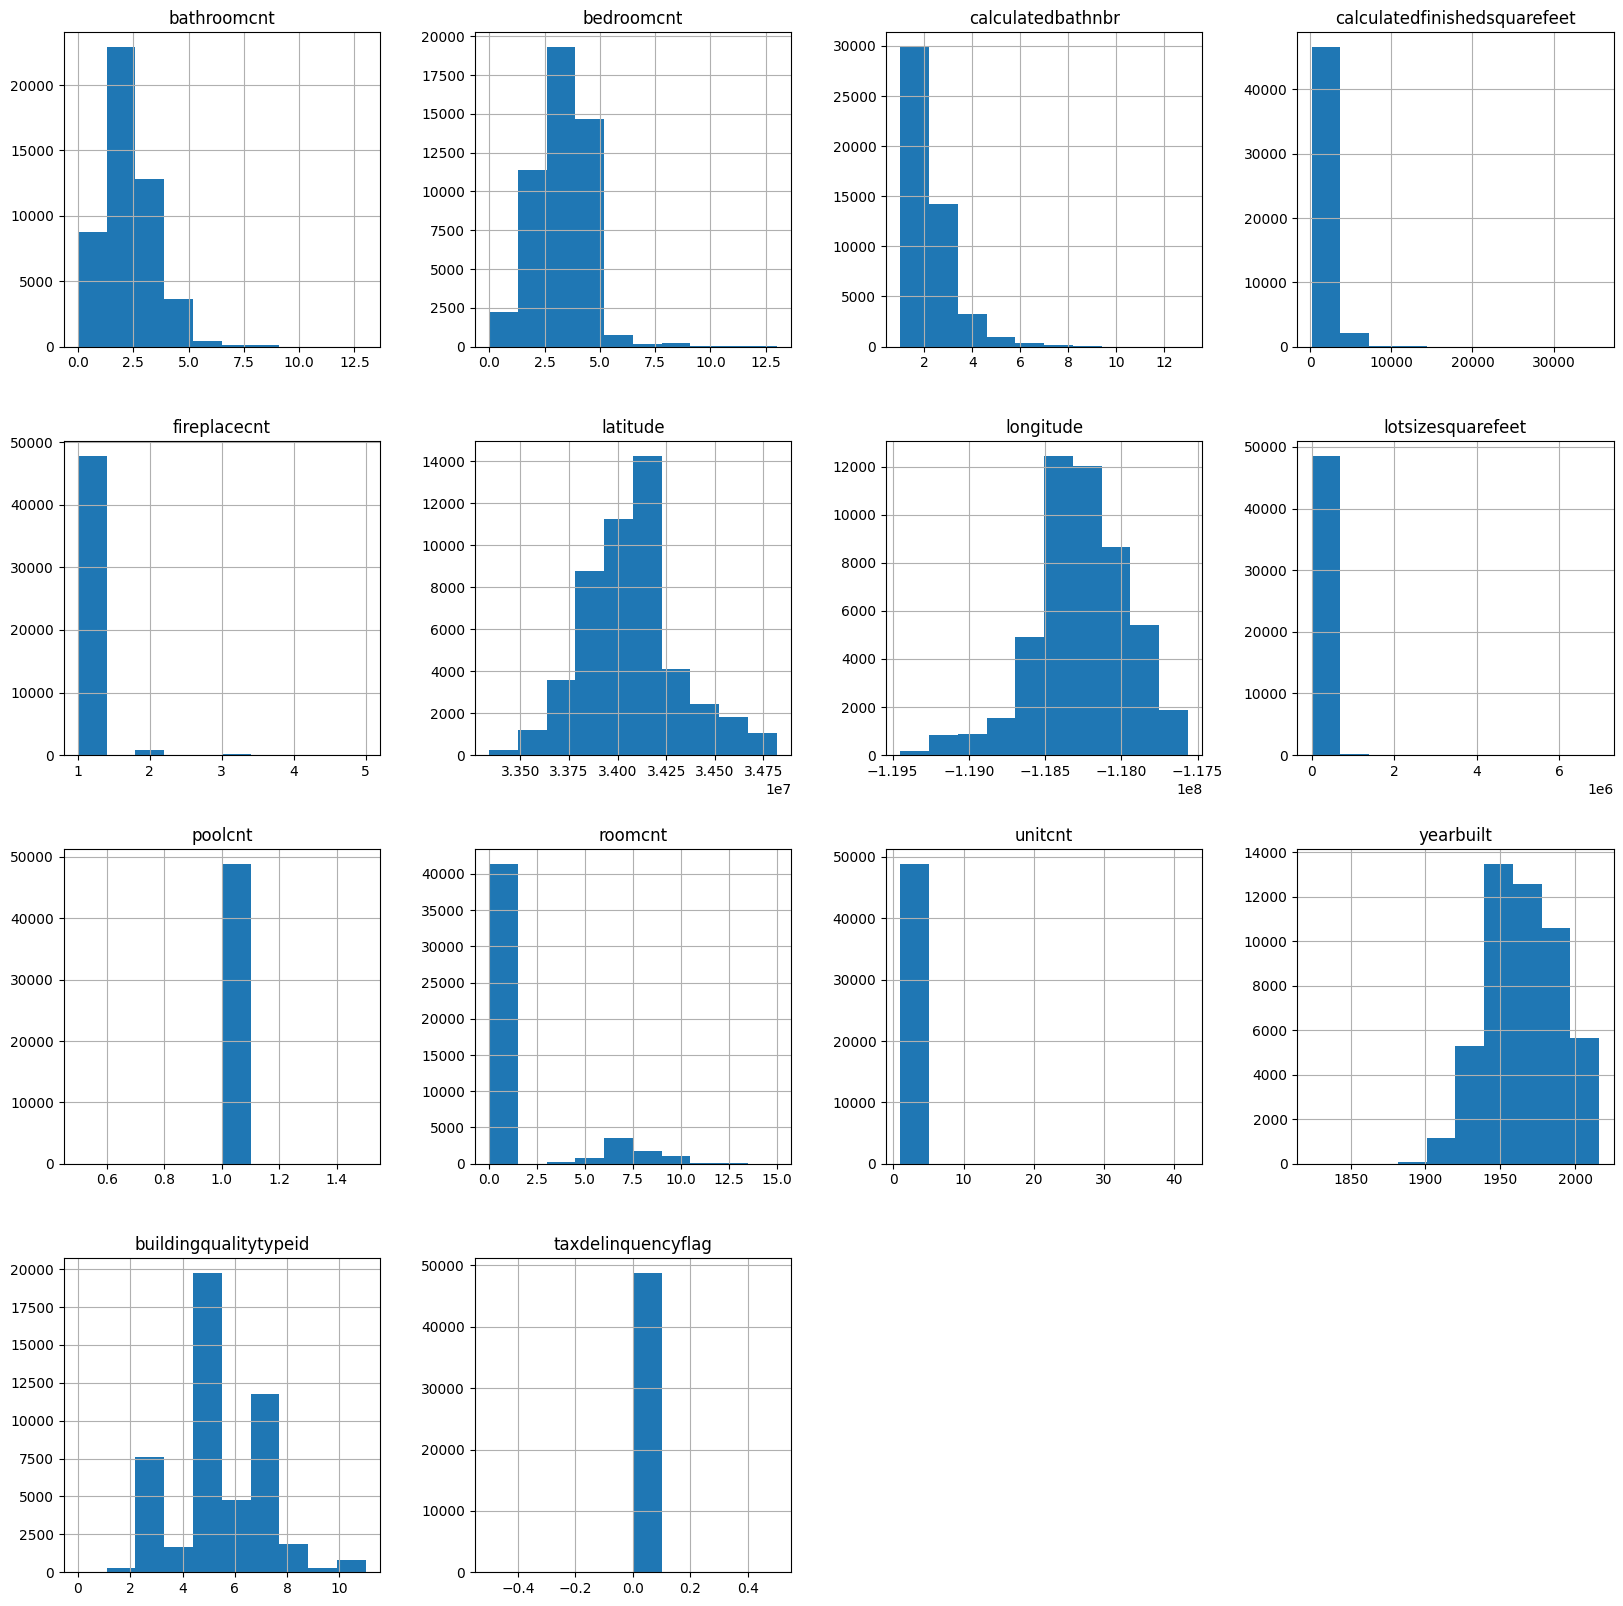

In [ ]:
X_train_3f.hist(figsize=(20,20));

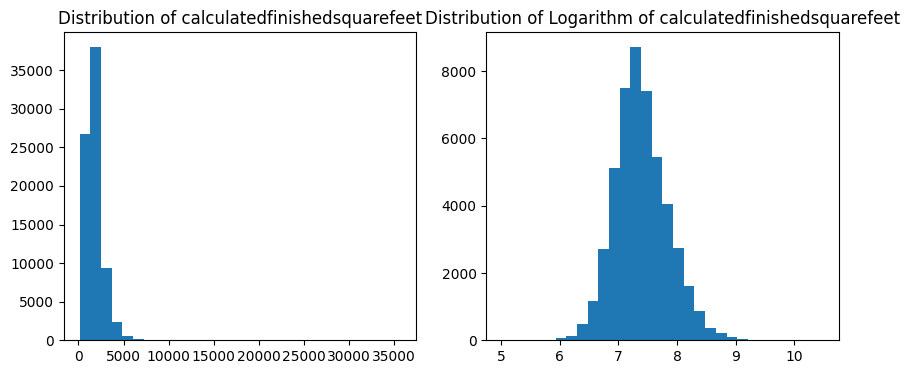

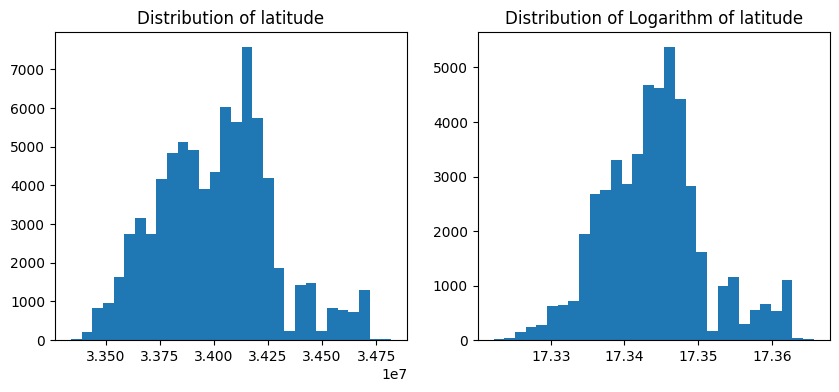

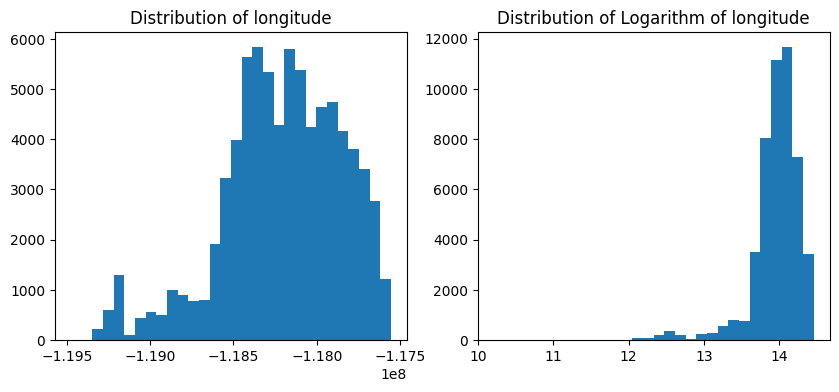

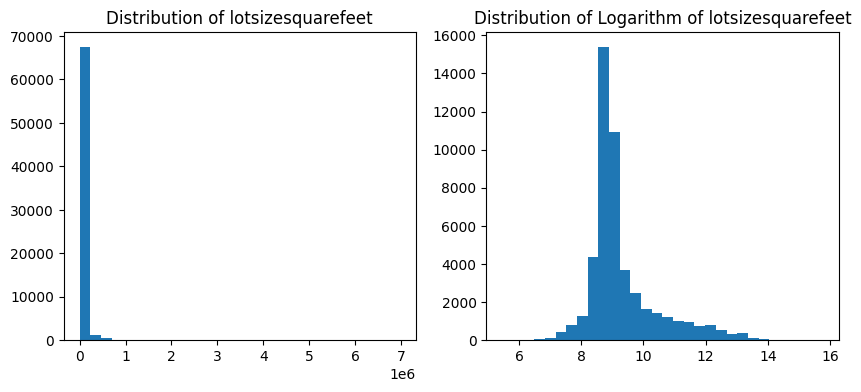

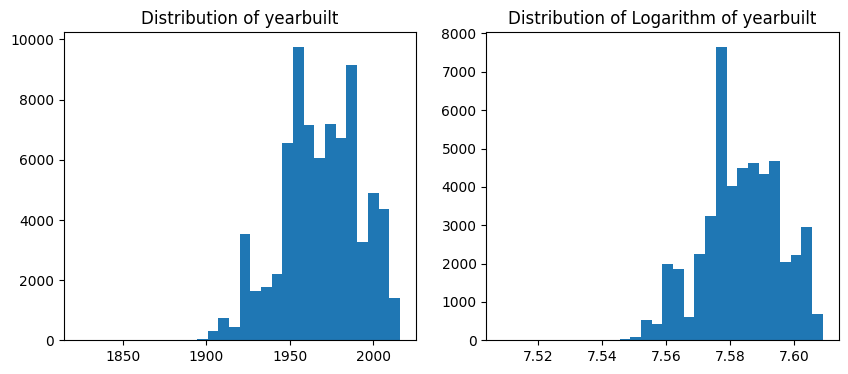

In [ ]:
df_log = X_train_3f.copy()


df_log['calculatedfinishedsquarefeet'] = np.log(df_log['calculatedfinishedsquarefeet'])
df_log['latitude'] = np.log(df_log['latitude'])
c= np.abs(-1.194754e+08) +1
df_log['longitude'] = np.log(df_log['longitude'] +c)
df_log['lotsizesquarefeet'] = np.log(df_log['lotsizesquarefeet'])
df_log['yearbuilt'] = np.log(df_log['yearbuilt'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df['calculatedfinishedsquarefeet'], bins=30)
axes[0].set_title('Distribution of calculatedfinishedsquarefeet')
axes[1].hist(df_log['calculatedfinishedsquarefeet'], bins=30)
axes[1].set_title('Distribution of Logarithm of calculatedfinishedsquarefeet')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df['latitude'], bins=30)
axes[0].set_title('Distribution of latitude')
axes[1].hist(df_log['latitude'], bins=30)
axes[1].set_title('Distribution of Logarithm of latitude')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df['longitude'], bins=30)
axes[0].set_title('Distribution of longitude')
axes[1].hist(df_log['longitude'], bins=30)
axes[1].set_title('Distribution of Logarithm of longitude')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df['lotsizesquarefeet'], bins=30)
axes[0].set_title('Distribution of lotsizesquarefeet')
axes[1].hist(df_log['lotsizesquarefeet'], bins=30)
axes[1].set_title('Distribution of Logarithm of lotsizesquarefeet')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df['yearbuilt'], bins=30)
axes[0].set_title('Distribution of yearbuilt')
axes[1].hist(df_log['yearbuilt'], bins=30)
axes[1].set_title('Distribution of Logarithm of yearbuilt')
plt.show()

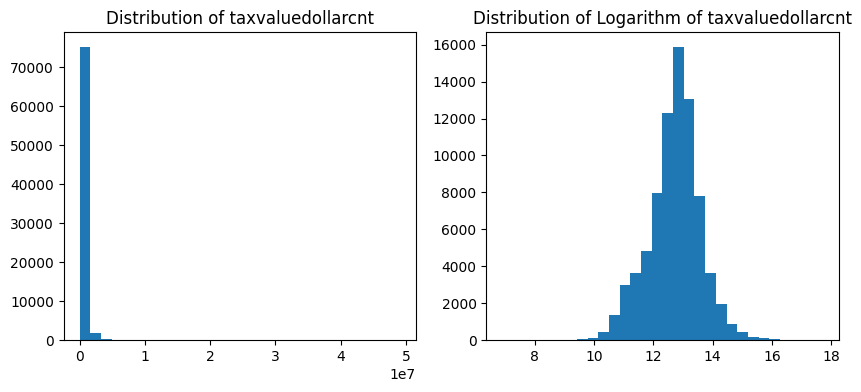

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df['taxvaluedollarcnt'], bins=30)
axes[0].set_title('Distribution of taxvaluedollarcnt')
axes[1].hist(np.log(df['taxvaluedollarcnt']), bins=30)
axes[1].set_title('Distribution of Logarithm of taxvaluedollarcnt')
plt.show()

#### **5.A Discussion:**

Describe the three feature engineering or preprocessing ideas you identified.

For each one, explain:

- Which feature(s) it would affect.
- Why you believe it may improve model performance.
- How you would determine in **Milestone 2** whether it actually improves the model (for example, by comparing appropriate evaluation metrics on a validation or test set).

> I would not choose removing highly correlated features, since in previous sections we dropped the columns that were highly likely to contain overlapping information. For example, the square footage columns, and the fireplaceflag column. Bathroomcnt and calculatedbathnbr are also highly correlated. Although both columns will contain much of the same information, the calculatedbathnbr column offers specific information that may be beneficial to analysis. Depending on model choice, we may decide to exclude one column to reduce redundancy.
>
> **1.Binning continuous variables** could be valuable for continuous variables such as latitude, longitude, yearbuilt, calculatedfinishedsquarefeet, lotsizesquarefeet, and the target value taxvaluedollarcnt. Because the distribution of many of these features skewed, we can utilize equal frequency binning. Lattitude and longitude  could be used for locational grouping. Similarly, we could create a new version of the target feature, taxvaluedollarcnt, for use in categorical models. Although, as this technique treats values within the same bin we will have to make sure that there is no information loss. The range of these columns is expansive and contains thousands of unique values, so binning these values could help simplify the model; making it more optimal during training. Equal frequency binning and having approximately the same number of samples in each bin helps take into account the skew of the distribution of these column. As mentioned in the first section, RMSE is a good metric to use to evaluation this transformation because we would be able to see exactly how much our predictions differ from actual tax values in dollar terms. This would be an efficent way to see if there is any information loss.
>
> **2.Log transformation** takes data that is skewed and manipulates it to become more balanced. It takes the logarithm of each value to compress the large values and spread out the small numbers; this approach brings distributions more toward a normal distribution. This transformation will be the most beneficial on the target column taxvaluedollarcnt. With the number of outliers within this column, log transformation will create a more normal distribution, as shown above, that is more reliable within a machine learning model. It is interesting to see that the outliers in the column are more balanced after the transformation; In the initial column the outliers were all above the upper bound, but in the log transformed version the outliers are split more evenly above the upper bound and below the lower bound. This transformation could also be used on the other continuous variables such as calculatedfinishedsquarefeet and lotsizesquarefeet. Taking the logarithm of each column reduces skew and stabilizes variation, which will improve model training especially within linear regression. We would exclude lattitude, longistude, and year built from these transformations. Linear Regression assumes that the residuals follow a normal distribution, which is essential for accurate hypothesis testing and confidence intervals. To determine if this method actually improves the model we can compare the MSE of both models, since this metric is most useful when the dataset contains outliers since it can amplify the impact of outliers; We would be able to tell if the log transformation took care of the outliers in the transformed columns. It would be interesting to see the change in MSE and compare this difference with the change in MAE where the outliers do not affect the materic's score as much.
>
>**3.scaling or normalization** transforms inputs to comparable scales. We have three main options:


1.   robust scaling the training data is used to derive Q3, Q1 and median and then these values are used to perform the transformations when applied to new data X_scaled =(X- X_median)/(X_Q3-X_Q1).
2.   min-max normalization X_scaled =(X-X_min)/(X_max-X_min)This method is normally showcased as a way to scale variables with outliers in them to a range of [0,1] This method offers easier interpretation as the transformations can be easily reversed.
3.   Normalization scales columns down to a range of [-1,1] and keeps the range between the values intact by finding the z-score of each value z=(xi-mean)/std. This standardization converts the mean of the column to 0 and the standard deviation to 1. With a model such as linear regression this could be that best choice as normalized data will enhance model performance and improve its accuracy. The scaled data also offers easier intepretation of the relationships of predictors and comparisons in trends since all data is being interpreted on the same scale. This would put the continuous variable in the same range as our categorical columns:roomcnt, bathroomcnt, bedroomcnt, calculatedbathnbr, fireplacecnt, poolcnt, roomcnt, unitcnt, and taxdelinquincyflag. A combination of RMSE, MAE, and MSE would give us a well rounded idea about the execution of the model. We would be able to see how far in dollars our predictions are from the actual values and with MAE and MSE we can see how the outliers affected the model before and after the transition. Removing outliers, as mentioned in the first section of this milestone, if there are too many outliers the RMSE will skew off the average. If we want to use RMSE as an evaluation metric to see if the model improves, we do not want outliers to skew the average. Especially within the taxvaluedollarcnt column there are clear outliers (shown in sections 2B and 3C). Models like linear regression get confused easily by extreme values. However these points, so far are assumed to be natural, so they are beneficial to the analysis; If through further exploration of the dataset we see that some data points could be due to processing or entrying data error we can think about this approach.


## Part 5.B: Prioritize Your Ideas

Not all feature engineering ideas are equally promising.

Based on your investigation, select the **two** ideas you believe are most likely to improve model performance.

Briefly explain why you selected these ideas over the others.

No code is required for this section.

#### **5.B Discussion:**

Suppose you had time to evaluate only **two** feature engineering or preprocessing ideas in **Milestone 2**.

For each one, explain:

- Which idea you would prioritize.
- Why you believe it is the most promising.
- What evidence from your exploratory analysis (such as feature distributions, missing values, feature relationships, or other observations) led you to this conclusion.

>**1.log transformation:** I would prioritize log transformation on the target column(taxvaluedollarcnt) and the continuous predictors(calculatedfinishedsquarefeet and lotsizesquarefeet). I chose this feature engineering technique over the other options because this helps bring the continuous predictors to a normal distribution. By having a more normal distribution rather than a skewed distribution, the model we create can learn patterns more effectively and give a more accurate representation of the underlying relationships within the data; Each feature will contribute to the model proportionately. By looking at the feature distributions above in this section, you can see that the continuous variables are all skewed to the right. After applying np.log to these continuous feature and the target column each was brought to a more normal distribution (also shown above). Taking the logarithm of these continuous variables this will also help scale the columns toward a smaller range. Although further scaling would need to be done to have the values in all columns fall into a consistent range.
>
>**2.scaling or normalization:** I would prioritize scaling or normalization for the dataset because the columns within the housing dataset all contain data in different ranges. For example, if we keep the lotsizesquarefeet column ranging from [256,6971010] and roomcnt that ranges [0,15] the model could give a higher weight automatically to the lotsizesquarefeet column because of the significantly higher range. A difference of 10 is a significant change in the roomcnt column, but in the lotsizesquarefeet column it would be a rather insignificant change due to the vastness of the range. But are we 100% the that lot size is a better predictor of a home value than the room count? In this case I think we can assume this, but we can not be 100% about every combination of predictors. Scaling would help the model not only become more simplistic, but also cause a reduction in bias by offering an equal training for each column. Also, by converting all features to a consistent range, it is easier to understand their relative impact on predictions and the model is able to maintain a higher interpredibility.
>
>As shown in section 3C, the columns within the housing dataset contain many outliers. For example, in our target column, taxvaluedollarscnt, outliers account for 6.94% of the given model. If we remove the outliers we lose a lot of valuable information. So, I would not choose to remove the outliers first; If the outlier is a natural point, then it should be left in the dataset. More interpretation would have to be done with the data to see if the point(s) could be classified as an outlier from a data entry error. Or we have to train and test a model with and without the outliers to test and see if the outlier affects the model. Rather than remove the outliers we would first try transformations on the columns to reduce the impact of the extreme outliers.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |



## Appendix 3: Flowchart for Identifying Feature Types

The following flowchart can help you identify the statistical type of each feature and determine an appropriate encoding strategy for categorical variables.

![Screenshot 2026-06-28 at 9.25.25 AM.png](attachment:87ba406d-4f6b-4e03-825a-17f4941bb5ac.png)